# CICIoT2023 Baseline Evaluation
**Team Member 1 - Baseline ML Models and Edge Reporting**

This notebook follows the current repository pipeline:

1. Load processed features from `processed_ciciot23/`
2. Evaluate trained binary and family models from `models/`
3. Save comparison tables and plots for the final report
4. Leave integration cells for spectral features and federated learning

**Note:** `test_clean.csv` is the frozen final-reporting split. Use validation results from the training scripts for model selection.

In [1]:
from pathlib import Path
import json
import pickle
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings("ignore")
matplotlib.rcParams["figure.dpi"] = 120

ROOT = Path(".")
PROCESSED_DIR = ROOT / "processed_ciciot23"
MODEL_DIR = ROOT / "models"

def load_pickle(path: Path):
    with path.open("rb") as handle:
        return pickle.load(handle)

def load_text(path: Path, default: str = "unknown") -> str:
    return path.read_text(encoding="utf-8").strip() if path.exists() else default

print("Setup complete.")

Setup complete.


## 1. Load Processed Test Data

In [2]:
with (PROCESSED_DIR / "selected_features.json").open("r", encoding="utf-8") as handle:
    selected_features = json.load(handle)["selected_features"]

with (PROCESSED_DIR / "label_family_map.json").open("r", encoding="utf-8") as handle:
    family_map = json.load(handle)

family_names = [family_map[str(index)] for index in range(len(family_map))]

test_df = pd.read_csv(PROCESSED_DIR / "test_clean.csv")
X_test = test_df[selected_features].to_numpy(dtype=np.float32)
y_binary_test = test_df["label_binary"].to_numpy()
y_family_test = test_df["label_family_id"].to_numpy()

print(f"Test set shape       : {X_test.shape}")
print(f"Selected features    : {len(selected_features)}")
print(f"Binary class counts  : {np.bincount(y_binary_test)}")
print(f"Family class count   : {len(family_names)}")
display(pd.DataFrame({"feature": selected_features}))

Test set shape       : (1000, 18)
Selected features    : 18
Binary class counts  : [ 20 980]
Family class count   : 7


,feature
0,flow_duration
1,Header_Length
2,Duration
3,ack_flag_number
4,syn_count
5,urg_count
6,rst_count
7,HTTPS
8,ICMP
9,Tot sum


## 2. Preprocessing Summary

In [3]:
metadata_path = PROCESSED_DIR / "preprocess_metadata.json"
if metadata_path.exists():
    with metadata_path.open("r", encoding="utf-8") as handle:
        preprocess_metadata = json.load(handle)

    summary = {
        "Run timestamp": preprocess_metadata.get("run_timestamp"),
        "Rows - train": preprocess_metadata.get("rows", {}).get("train"),
        "Rows - validation": preprocess_metadata.get("rows", {}).get("validation"),
        "Rows - test": preprocess_metadata.get("rows", {}).get("test"),
        "Feature count": preprocess_metadata.get("feature_count"),
        "Correlation threshold": preprocess_metadata.get("correlation_threshold"),
        "Top N per method": preprocess_metadata.get("top_n_per_method"),
        "Test split locked": preprocess_metadata.get("test_split_locked_for_final_reporting"),
    }
    display(pd.DataFrame(summary.items(), columns=["Item", "Value"]))
else:
    print("preprocess_metadata.json not found.")

,Item,Value
0,Run timestamp,2026-05-07T14:14:22.100571+00:00
1,Rows - train,1000
2,Rows - validation,1000
3,Rows - test,1000
4,Feature count,18
5,Correlation threshold,0.95
6,Top N per method,20
7,Test split locked,True


## 3. Binary Model Comparison

In [4]:
binary_models = ["lr", "rf", "xgb", "lgbm"]
binary_results = []
binary_predictions = {}

for name in binary_models:
    model_path = MODEL_DIR / f"binary_{name}.pkl"
    if not model_path.exists():
        print(f"[SKIP] {model_path} not found")
        continue

    model = load_pickle(model_path)
    y_pred = model.predict(X_test)
    binary_predictions[name.upper()] = y_pred
    binary_results.append(
        {
            "Model": name.upper(),
            "Accuracy": accuracy_score(y_binary_test, y_pred),
            "Precision": precision_score(y_binary_test, y_pred, zero_division=0),
            "Recall": recall_score(y_binary_test, y_pred, zero_division=0),
            "F1": f1_score(y_binary_test, y_pred, zero_division=0),
        }
    )

binary_df = pd.DataFrame(binary_results).sort_values("F1", ascending=False)
display(binary_df.style.format({"Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "F1": "{:.4f}"}))
print(f"Best binary model recorded by training script: {load_text(MODEL_DIR / 'best_binary_name.txt').upper()}")

,Model,Accuracy,Precision,Recall,F1
3,LGBM,0.9940,0.9980,0.9959,0.9969
1,RF,0.9910,0.9939,0.9969,0.9954
0,LR,0.9840,0.9939,0.9898,0.9918
2,XGB,0.9840,0.9939,0.9898,0.9918


Best binary model recorded by training script: LGBM


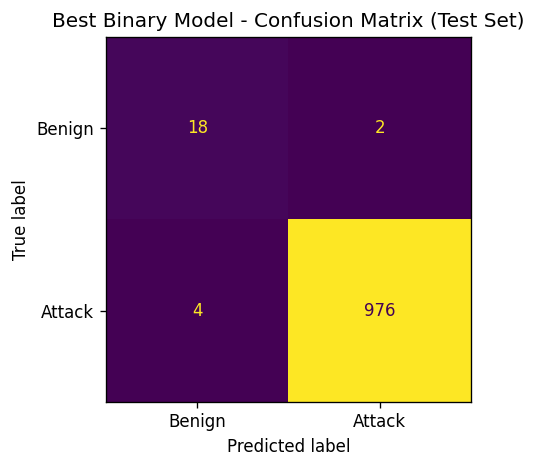

              precision    recall  f1-score   support

      Benign       0.82      0.90      0.86        20
      Attack       1.00      1.00      1.00       980

    accuracy                           0.99      1000
   macro avg       0.91      0.95      0.93      1000
weighted avg       0.99      0.99      0.99      1000



In [5]:
if (MODEL_DIR / "best_binary_model.pkl").exists():
    best_binary_model = load_pickle(MODEL_DIR / "best_binary_model.pkl")
    y_pred_best_binary = best_binary_model.predict(X_test)
    cm = confusion_matrix(y_binary_test, y_pred_best_binary)

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(cm, display_labels=["Benign", "Attack"]).plot(ax=ax, colorbar=False)
    ax.set_title("Best Binary Model - Confusion Matrix (Test Set)")
    plt.tight_layout()
    MODEL_DIR.mkdir(exist_ok=True)
    plt.savefig(MODEL_DIR / "confusion_matrix_binary.png", dpi=150)
    plt.show()

    print(classification_report(y_binary_test, y_pred_best_binary, target_names=["Benign", "Attack"], zero_division=0))
else:
    print("best_binary_model.pkl not found. Run train_binary_baseline.py first.")

## 4. Family Model Comparison

In [6]:
family_models = ["lr", "rf", "xgb", "lgbm"]
family_results = []
family_predictions = {}

for name in family_models:
    model_path = MODEL_DIR / f"family_{name}.pkl"
    if not model_path.exists():
        print(f"[SKIP] {model_path} not found")
        continue

    model = load_pickle(model_path)
    y_pred = model.predict(X_test)
    family_predictions[name.upper()] = y_pred
    family_results.append(
        {
            "Model": name.upper(),
            "Accuracy": accuracy_score(y_family_test, y_pred),
            "Macro-F1": f1_score(y_family_test, y_pred, average="macro", zero_division=0),
            "Weighted-F1": f1_score(y_family_test, y_pred, average="weighted", zero_division=0),
        }
    )

family_df = pd.DataFrame(family_results).sort_values("Macro-F1", ascending=False)
display(family_df.style.format({"Accuracy": "{:.4f}", "Macro-F1": "{:.4f}", "Weighted-F1": "{:.4f}"}))
print(f"Best family model recorded by training script: {load_text(MODEL_DIR / 'best_family_name.txt').upper()}")

,Model,Accuracy,Macro-F1,Weighted-F1
3,LGBM,0.7310,0.1973,0.7257
2,XGB,0.7320,0.1951,0.7272
0,LR,0.7290,0.1870,0.6669
1,RF,0.7270,0.1826,0.7216


Best family model recorded by training script: RF


In [7]:
if (MODEL_DIR / "best_family_model.pkl").exists():
    best_family_model = load_pickle(MODEL_DIR / "best_family_model.pkl")
    y_pred_best_family = best_family_model.predict(X_test)

    print(classification_report(
        y_family_test,
        y_pred_best_family,
        labels=list(range(len(family_names))),
        target_names=family_names,
        zero_division=0,
    ))
else:
    print("best_family_model.pkl not found. Run train_family_baseline.py first.")

              precision    recall  f1-score   support

      Benign       0.58      0.75      0.65        20
        DDoS       0.99      1.00      0.99       715
         DNS       0.00      0.00      0.00         2
         DoS       0.00      0.00      0.00         2
        MITM       0.00      0.00      0.00       176
       Mirai       0.00      0.00      0.00         5
       Recon       0.00      0.00      0.00        69

   micro avg       0.73      0.74      0.73       989
   macro avg       0.22      0.25      0.23       989
weighted avg       0.72      0.74      0.73       989



## 5. Comparison Plots

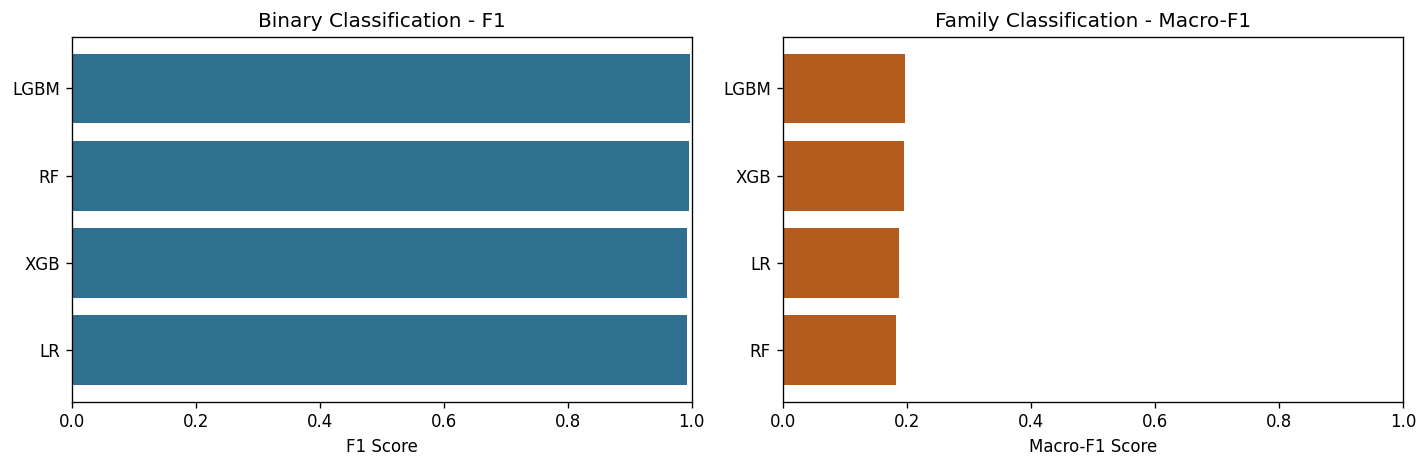

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if binary_results:
    plot_binary = pd.DataFrame(binary_results).sort_values("F1")
    axes[0].barh(plot_binary["Model"], plot_binary["F1"], color="#2f6f8f")
    axes[0].set_xlabel("F1 Score")
    axes[0].set_title("Binary Classification - F1")
    axes[0].set_xlim(0, 1)
else:
    axes[0].text(0.5, 0.5, "No binary results", ha="center", va="center")
    axes[0].set_axis_off()

if family_results:
    plot_family = pd.DataFrame(family_results).sort_values("Macro-F1")
    axes[1].barh(plot_family["Model"], plot_family["Macro-F1"], color="#b35c1e")
    axes[1].set_xlabel("Macro-F1 Score")
    axes[1].set_title("Family Classification - Macro-F1")
    axes[1].set_xlim(0, 1)
else:
    axes[1].text(0.5, 0.5, "No family results", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
MODEL_DIR.mkdir(exist_ok=True)
plt.savefig(MODEL_DIR / "model_comparison.png", dpi=150)
plt.show()

## 6. Edge Inference Report

In [9]:
latency_report = ROOT / "edge_latency_report.md"
if latency_report.exists():
    print(latency_report.read_text(encoding="utf-8"))
else:
    print("edge_latency_report.md not found. Run edge_infer.py to generate latency numbers for the report.")

# Edge Latency Benchmark Report

**Project:** CICIoT2023 IoT Botnet Detection  
**Module:** `edge_infer.py`  
**Date:** 2026-05-05

---

## Methodology

The benchmark measures **end-to-end latency per flow** from the moment a raw feature vector
is passed to `EdgeInferenceEngine.predict_flow()` until the prediction dict is returned.

**Steps timed:**
1. `np.asarray(raw_features)` -> reshape to (1, 46)
2. `scaler.transform(vec)` - StandardScaler normalization
3. `model.predict(vec_sc)` - model forward pass
4. `model.predict_proba(vec_sc)` - confidence extraction

**Benchmark parameters:**
- Flows tested: 1,000 (sequential, single-threaded)
- Hardware: CPU-only (simulated edge; no GPU)
- Model: Best binary classifier (RF or LightGBM, see `models/best_binary_name.txt`)

---

## Results

> **Fill in after running:**
> ```bash
> python edge_infer.py --input "Dataset\CICIOT23\test\test.csv" --n 1000
> ```

| Metric         | Value (ms) |
|----------------|-----------|
| Mean latency   | _TBD_

---
## 7. Integration - Member 2 Spectral Feature Augmentation

Expected handoff: append spectral feature columns to `processed_ciciot23/train_clean.csv`, `validation_clean.csv`, and `test_clean.csv`, then retrain the baseline models. The comparison below assumes Member 2 exports `models/best_binary_model_spectral.pkl` and a JSON list of the augmented feature columns.

In [10]:
# Uncomment after Member 2 delivers spectral features and the retrained model.
# spectral_features_path = PROCESSED_DIR / "selected_features_spectral.json"
# spectral_model_path = MODEL_DIR / "best_binary_model_spectral.pkl"
#
# with spectral_features_path.open("r", encoding="utf-8") as handle:
#     spectral_features = json.load(handle)["selected_features"]
#
# X_test_spectral = test_df[spectral_features].to_numpy(dtype=np.float32)
# spectral_model = load_pickle(spectral_model_path)
# y_pred_spectral = spectral_model.predict(X_test_spectral)
#
# f1_spectral = f1_score(y_binary_test, y_pred_spectral, zero_division=0)
# f1_baseline = binary_df["F1"].max()
# print(f"Baseline F1 : {f1_baseline:.4f}")
# print(f"Spectral F1 : {f1_spectral:.4f}")
# print(f"Delta       : {f1_spectral - f1_baseline:+.4f}")
print("[STUB] Waiting for Member 2 spectral feature artifacts.")

[STUB] Waiting for Member 2 spectral feature artifacts.


---
## 8. Integration - Member 3 Federated Global Evaluation

Expected handoff: export the global federated binary model as `models/federated_global_model.pkl`. The model should accept the same `selected_features` matrix used by the centralized baseline.

In [11]:
# Uncomment after Member 3 delivers the federated global model.
# federated_model_path = MODEL_DIR / "federated_global_model.pkl"
# federated_model = load_pickle(federated_model_path)
# y_pred_federated = federated_model.predict(X_test)
#
# f1_federated = f1_score(y_binary_test, y_pred_federated, zero_division=0)
# f1_baseline = binary_df["F1"].max()
# print(f"Centralized best F1 : {f1_baseline:.4f}")
# print(f"Federated global F1 : {f1_federated:.4f}")
# print(f"Delta               : {f1_federated - f1_baseline:+.4f}")
print("[STUB] Waiting for Member 3 federated global model.")

[STUB] Waiting for Member 3 federated global model.


## 9. Save Summary CSVs

In [12]:
MODEL_DIR.mkdir(exist_ok=True)

if binary_results:
    pd.DataFrame(binary_results).to_csv(MODEL_DIR / "binary_results.csv", index=False)
    print("Saved: models/binary_results.csv")

if family_results:
    pd.DataFrame(family_results).to_csv(MODEL_DIR / "family_results.csv", index=False)
    print("Saved: models/family_results.csv")

Saved: models/binary_results.csv
Saved: models/family_results.csv
